# Variable-mean noise: LN models fitted in Python

**The experiment.** `edu.washington.riekelab.{rieke,turner}.protocols.VariableMeanNoise`
delivers Gaussian noise of constant contrast **through an LED** while the mean light level
steps periodically. 

The two packages carry the same protocol — the recorded epoch parameters are identical
(`lightMean`, `stdv`, `seed`, `led`, `stimTime`, `frequencyCutoff`, `numberOfFilters`) — so
the search matches both and reports which variant each block came from.

Model fitting is **cascadegraph**, vendored into the package at
`retinanalysis.utils.cascadegraph` — the Python port of the same library the MATLAB used.
Nothing here reimplements a filter or a sigmoid.

In [1]:
import sys
import time
from pathlib import Path

if sys.version_info[:2] != (3, 11):
    raise RuntimeError(
        f'This notebook requires the retinanalysis Python 3.11 kernel; '
        f'got Python {sys.version.split()[0]} at {sys.executable}')
import_started = time.perf_counter()

import json
import numpy as np
import pandas as pd
from IPython.display import display

import retinanalysis as ra
from retinanalysis.SCutils import explore as sc

# The analysis module sits beside this notebook: it is specific to this project
# and reads the project's own saved MATLAB file.
sys.path.insert(0, str(Path.cwd()))
import variable_mean_noise as vmn

print(f'Python {sys.version.split()[0]} | {sys.executable}')
print(f'Data-entry list: {vmn.DEFAULT_SUMMARY_PATH.name} '
      f'(exists: {vmn.DEFAULT_SUMMARY_PATH.exists()})')
print(f'Imports ready in {time.perf_counter() - import_started:.2f} s')

Python 3.11.13 | /Users/chrischen/opt/anaconda3/envs/retinanalysis/bin/python
Data-entry list: rodVariableMeanNoise.mat (exists: True)
Imports ready in 0.64 s


## 1. The data-entry list

`load_summary` reads `matlabSummary/rodVariableMeanNoise.mat` — the cells the MATLAB analysis
was run on. This is **which cells to analyze**, not the analysis itself; the fits it also
carries are used only in §5, as a reference to check the Python pipeline against.

Two things the roster flags rather than fixes: `duplicate` marks (date, cell, mode) triples
saved more than once, because the MATLAB appended a re-analysis instead of replacing the
original; and `epoch_len_ms` is NaN where `epochLen` holds an NDF list, because it was written
as `selectedNodes{1}.parent.splitValue` — whatever the parent tree node happened to split on.

In [2]:
roster = vmn.load_summary(show=True)

sc.scroll_table(
    roster[['index', 'exp_date', 'cell_label', 'cell_type', 'rec_type',
            'epoch_len_ms', 'tau_low', 'tau_high', 'is_example', 'duplicate']].round(2),
    height=340, num_cols=('index', 'epoch_len_ms', 'tau_low', 'tau_high'))

53 saved cells | 16 dates | 15 rows in duplicated groups
rec_type   exc  extracellular
cell_type                    
OnMidget    11             10
OnParasol   14             18


index,exp_date,cell_label,cell_type,rec_type,epoch_len_ms,tau_low,tau_high,is_example,duplicate
0,2020/07/27,cell5,OnParasol,extracellular,60000.0,11.87,15.94,False,False
1,2020/08/23,cell3,OnParasol,extracellular,55000.0,10.59,14.76,True,False
2,2020/08/23,cell6,OnParasol,extracellular,56000.0,9.07,0.05,True,False
3,2020/08/23,cell7,OnParasol,extracellular,60000.0,7.33,25909.59,True,False
4,2020/08/09,cell1,OnMidget,extracellular,60000.0,7.38,12.81,False,False
5,2020/08/09,cell3,OnParasol,extracellular,50000.0,9.54,12.29,False,False
6,2020/08/23,cell4,OnMidget,extracellular,55000.0,16.2,14.03,False,False
7,2021/04/25,cell1,OnParasol,extracellular,50000.0,7.0,7.65,True,False
8,2021/04/25,cell2,OnParasol,extracellular,50000.0,5.53,39.91,True,False
9,2021/04/25,cell3,OnParasol,extracellular,50000.0,6.06,28.17,True,False


'\n<style>\n.ra-tbl { overflow: auto; }\n.ra-tbl table { border-collapse: collapse; font-size: 12.5px;\n                font-variant-numeric: tabular-nums; }\n.ra-tbl th { position: sticky; top: 0; z-index: 1; text-align: left;\n             font-weight: 600; padding: 4px 12px 4px 0;\n             border-bottom: 1px solid rgba(128,128,128,0.6);\n             background: var(--jp-layout-color0, #fff); }\n.ra-tbl td { padding: 2px 12px 2px 0; vertical-align: top;\n             white-space: nowrap; }\n.ra-tbl tr.grp > td { border-top: 1px solid rgba(128,128,128,0.28); }\n.ra-tbl td.num { text-align: right; }\n.ra-tbl td.lead { font-weight: 600; }\n.ra-tbl summary { cursor: pointer; margin: 2px 0; }\n</style>\n<div class="ra-tbl" style="max-height:340px"><table><thead><tr><th>index</th><th>exp_date</th><th>cell_label</th><th>cell_type</th><th>rec_type</th><th>epoch_len_ms</th><th>tau_low</th><th>tau_high</th><th>is_example</th><th>duplicate</th></tr></thead><tbody><tr><td class="num">0</td

## 2. Search the database, and intersect

The same discovery step as section 1 of the cone-disc notebooks, then `match_roster` joins on
calendar date and `condition_table` expands the matched experiments into the table to work
from — one row per block, carrying the cell it came from, what it presented, and how it was
actually recorded.

Matching is on **date only**. The saved file records `yyyy/mm/dd` with no rig suffix, so it
cannot distinguish two rigs run on one day. Cell labels are not matched either — the saved
labels come from the riekesuite source tree and the database keeps its own — so the roster
narrows the search to a date and the **cell is chosen from the table below**, by label and type.

**Recording type is verified, not trusted.** These blocks carry no `onlineAnalysis` at all, so
there is no label to believe and the amplifier decides. Series resistance above zero means the
cell was held whole-cell, and the polarity comes from the sign of the current — inward
(negative mean) is `exc`, outward is `inh`. A reading of exactly zero is *not* by itself
cell-attached, since it also happens when whole-cell compensation was never run, so it is
confirmed against the trace and only one that really contains spikes is called
`extracellular`. `rec_note` records what was decided and on what evidence.

**Expect a small intersection.** Most saved dates are from 2020–2022 and predate this
database; `reachable` is what reports it.

In [3]:
blocks = vmn.find_blocks(show=True)

matched = vmn.match_roster(roster, blocks, show=True)
reachable = matched[matched.reachable]
REACHABLE_EXPERIMENTS = sorted({e for row in reachable.experiments
                                for e in row.split(', ') if e})
print(f'\nexperiments to work from: {REACHABLE_EXPERIMENTS}')

1720 blocks | 136 experiments
protocol_name
edu.washington.riekelab.rieke.protocols.VariableMeanNoise     1483
edu.washington.riekelab.turner.protocols.VariableMeanNoise     237


exp_name,block_id,protocol_name,ndfs,filter_wheel_ndf,fixed_ndf_source
2019-03-12_E,5911,edu.washington.riekelab.rieke.protocols.VariableMeanNoise,E2,,stage
2019-03-12_E,5912,edu.washington.riekelab.rieke.protocols.VariableMeanNoise,E2,,stage
2019-03-12_E,5913,edu.washington.riekelab.rieke.protocols.VariableMeanNoise,E2,,stage
2019-03-12_E,5936,edu.washington.riekelab.rieke.protocols.VariableMeanNoise,E2,,stage
2019-03-12_E,5937,edu.washington.riekelab.rieke.protocols.VariableMeanNoise,E2,,stage
2019-03-12_E,5938,edu.washington.riekelab.rieke.protocols.VariableMeanNoise,E2,,stage
2019-03-12_E,5969,edu.washington.riekelab.rieke.protocols.VariableMeanNoise,E2,,stage
2019-03-12_E,5970,edu.washington.riekelab.rieke.protocols.VariableMeanNoise,E2,,stage
2019-03-12_E,5971,edu.washington.riekelab.rieke.protocols.VariableMeanNoise,E2,,stage
2019-03-12_E,5997,edu.washington.riekelab.rieke.protocols.VariableMeanNoise,E2,,stage


1 of 53 saved cells sit on a date the database has (1 of 16 dates)
 index   exp_date cell_label cell_type      rec_type  experiments  n_blocks
    18 2021/08/18      Cell2  OnMidget extracellular 2021-08-18_B         7

experiments to work from: ['2021-08-18_B']


### 2b. Finding the raw files: the saved dates are two days early

The database search above finds almost nothing, but the recordings are on disk. **The saved
`expDate` is two days early, across the board (an Ovation log issue)

So `SAVED_DATE_OFFSET_DAYS = 2` is applied as a **correction**, not searched for:
`corrected_date` is the date actually looked up, and it is the column to read rather than
`exp_date`. Within that date the cell is looked up **by label, case sensitively** — the saved
labels are `cell5` for the older entries and `Cell2` for the newer ones, and both appear in the
metadata as written — and the match is then confirmed against the cell type and against whether
that cell really has VariableMeanNoise blocks. The rig suffix on the filename (`_B`, `_G`)
separates two experiments recorded on the same day.


In [4]:
located = vmn.resolve_roster_files(roster, show=True)

cols = ['index', 'exp_date', 'corrected_date', 'cell_label', 'cell_type', 'rec_type',
        'exp_name', 'rig', 'day_offset', 'matched_cell_type', 'match_quality',
        'h5_present', 'date_note']
sc.scroll_table(located[cols], height=380, num_cols=('index', 'day_offset'))

INGEST_EXPERIMENTS = sorted(located.loc[located.exp_name.ne(''), 'exp_name'].unique())
print(f'\n{len(INGEST_EXPERIMENTS)} experiments hold the saved cells:')
print('  ' + ', '.join(INGEST_EXPERIMENTS))

suspect = located[located.match_quality.ne('label+type+protocol')
                  & located.exp_name.ne('')]
if len(suspect):
    print(f'\n{len(suspect)} row(s) matched on less than all three — check before using:')
    display(suspect[['index', 'exp_date', 'corrected_date', 'cell_label', 'cell_type',
                     'exp_name', 'matched_cell_type', 'match_quality']])

saved dates corrected by +2 days (52 of 53 entries resolve there)
53 of 53 saved cells located on disk (53 with an h5)
match_quality
label+type+protocol    43
label                   5
label+protocol          4
label+type              1

1 entr(ies) did not resolve on the corrected date:
  2021/08/18 Cell2: corrected date 2021-08-20 has no matching file; resolved at +0 days instead -- verify


index,exp_date,corrected_date,cell_label,cell_type,rec_type,exp_name,rig,day_offset,matched_cell_type,match_quality,h5_present,date_note
0,2020/07/27,2020-07-29,cell5,OnParasol,extracellular,2020-07-29_G,G,2,RGC\ON-parasol,label+type+protocol,True,
1,2020/08/23,2020-08-25,cell3,OnParasol,extracellular,2020-08-25_G_scotopic,G,2,RGC\ON-parasol,label+type+protocol,True,
2,2020/08/23,2020-08-25,cell6,OnParasol,extracellular,2020-08-25_G,G,2,RGC\ON-parasol,label+type+protocol,True,
3,2020/08/23,2020-08-25,cell7,OnParasol,extracellular,2020-08-25_G,G,2,RGC\ON-parasol,label+type+protocol,True,
4,2020/08/09,2020-08-11,cell1,OnMidget,extracellular,2020-08-11_G,G,2,RGC\ON-midget,label+type+protocol,True,
5,2020/08/09,2020-08-11,cell3,OnParasol,extracellular,2020-08-11_G,G,2,RGC\ON-midget,label+protocol,True,
6,2020/08/23,2020-08-25,cell4,OnMidget,extracellular,2020-08-25_G,G,2,RGC\ON-midget,label+type+protocol,True,
7,2021/04/25,2021-04-27,cell1,OnParasol,extracellular,2021-04-27_B,B,2,RGC\ON-parasol,label+type+protocol,True,
8,2021/04/25,2021-04-27,cell2,OnParasol,extracellular,2021-04-27_B,B,2,RGC\ON-parasol,label+type+protocol,True,
9,2021/04/25,2021-04-27,cell3,OnParasol,extracellular,2021-04-27_B,B,2,RGC\ON-parasol,label+type+protocol,True,



17 experiments hold the saved cells:
  2020-07-29_G, 2020-08-11_G, 2020-08-25_G, 2020-08-25_G_scotopic, 2021-03-02_B, 2021-04-27_B, 2021-05-05_B, 2021-05-25_B, 2021-06-22_B, 2021-08-18_B, 2021-09-07_B, 2021-09-21_B, 2021-09-28_B, 2021-10-07_B, 2022-05-10_B, 2022-05-18_B, 2022-09-09_G

10 row(s) matched on less than all three — check before using:


,index,exp_date,corrected_date,cell_label,cell_type,exp_name,matched_cell_type,match_quality
5,5,2020/08/09,2020-08-11,cell3,OnParasol,2020-08-11_G,RGC\ON-midget,label+protocol
30,30,2022/09/07,2022-09-09,Cell2,OnParasol,2022-09-09_G,RGC\ON-midget,label
31,31,2022/09/07,2022-09-09,Cell1,OnParasol,2022-09-09_G,RGC\ON-midget,label
35,35,2022/09/07,2022-09-09,Cell4,OnMidget,2022-09-09_G,RGC\OFF-parasol,label
38,38,2021/02/28,2021-03-02,cell1,OnMidget,2021-03-02_B,RGC\ON-parasol,label+protocol
39,39,2021/02/28,2021-03-02,cell1,OnMidget,2021-03-02_B,RGC\ON-parasol,label+protocol
44,44,2021/09/19,2021-09-21,Cell3,OnMidget,2021-09-21_B,RGC\ON-parasol,label+protocol
48,48,2022/09/07,2022-09-09,Cell1,OnParasol,2022-09-09_G,RGC\ON-midget,label
49,49,2022/09/07,2022-09-09,Cell2,OnParasol,2022-09-09_G,RGC\ON-midget,label
50,50,2022/09/07,2022-09-09,Cell3,OnParasol,2022-09-09_G,RGC\ON-parasol,label+type


These experiments are **not in the DataJoint database yet**, which is why §2 found only one.
Their `h5` and `json` directories are already declared as ingest sources in `config.ini`
(`/Volumes/ChrisNewSSD/single_cell/{fred,chris}_data/`), so `ra.populate_database()` is the step
that would make them loadable through §3 — it is append-only for new dates, but it writes to the
database, so it is left as an explicit call rather than run from here.

The cell below only *checks* the files: that each h5 opens and that the metadata really contains
VariableMeanNoise blocks. Nothing is ingested and nothing is written.

In [5]:
import h5py

rows = []
for exp_name, group in located[located.exp_name.ne('')].groupby('exp_name'):
    entry = group.iloc[0]
    record = {'exp_name': exp_name, 'rig': entry.rig, 'n_saved_cells': len(group)}
    try:
        meta = json.loads(Path(entry.json_path).read_text())
        n_blocks = n_epochs = 0
        for animal in meta.get('animals', []):
            for prep in animal.get('preparations', []):
                for cell in prep.get('cells', []):
                    for grp in cell.get('epoch_groups', []):
                        for blk in grp.get('epoch_blocks', []):
                            if 'VariableMeanNoise' in str(blk.get('protocolID', '')):
                                n_blocks += 1
                                n_epochs += len(blk.get('epochs', []))
        record.update(vmn_blocks=n_blocks, vmn_epochs=n_epochs)
        with h5py.File(entry.h5_path, 'r') as handle:
            record['h5_readable'] = True
            record['h5_mb'] = round(Path(entry.h5_path).stat().st_size / 1e6)
    except Exception as exc:
        record.update(h5_readable=False, note=f'{type(exc).__name__}: {exc}')
    rows.append(record)

availability = pd.DataFrame(rows)
sc.scroll_table(availability, height=320,
                num_cols=('n_saved_cells', 'vmn_blocks', 'vmn_epochs', 'h5_mb'))
print(f"{int(availability.h5_readable.sum())} of {len(availability)} experiments open; "
      f"{int(availability.vmn_blocks.sum())} VariableMeanNoise blocks, "
      f"{int(availability.vmn_epochs.sum())} epochs")

exp_name,rig,n_saved_cells,vmn_blocks,vmn_epochs,h5_readable,h5_mb
2020-07-29_G,G,1,18,98,True,294
2020-08-11_G,G,7,29,840,True,601
2020-08-25_G,G,3,8,75,True,169
2020-08-25_G_scotopic,G,1,4,43,True,116
2021-03-02_B,B,2,4,38,True,359
2021-04-27_B,B,9,11,103,True,293
2021-05-05_B,B,2,2,23,True,139
2021-05-25_B,B,1,14,140,True,331
2021-06-22_B,B,3,6,56,True,572
2021-08-18_B,B,1,7,70,True,523


17 of 17 experiments open; 136 VariableMeanNoise blocks, 1820 epochs


### 2a. The table to work from

One row per block. `entry` is the handle §3 takes; `roster_index` points back to the saved
data-entry list for that date, so the MATLAB's own result for that cell can be pulled up in §5.

A row whose `lightMean` lists two values is a block that stepped between them — that is the one
to analyze. `resolve_modes=False` skips the amplifier check, which is the slow part, when only
the stimulus columns are wanted.

In [6]:
RESOLVE_MODES = True    # False to skip the amplifier check (much faster)

conditions = vmn.condition_table(
    exp_names=REACHABLE_EXPERIMENTS or [blocks.exp_name.iloc[0]],
    blocks=blocks, roster=roster, resolve_modes=RESOLVE_MODES, show=True)

for note in sorted({n for n in conditions.get('rec_note', []) if n}):
    print(f'  {note}')

7 block(s) | 1 experiment(s)
rec_type
extracellular    5
exc              2


entry,exp_name,cell_label,cell_type_short,rec_type,series_resistance_mohm,mean_current_pa,stimTime_ms,led,lightMean,stdv,n_epochs,block_id,roster_index
0,2021-08-18_B,Cell3,ON-midget,exc,0.0,-160.754,30000.0,UV LED,0.5,0.15,1,12726,18
1,2021-08-18_B,Cell6,ON-parasol,extracellular,0.0,-360.924,60000.0,UV LED,"0.5, 5","0.15, 1.5",13,12736,18
2,2021-08-18_B,Cell5,OFF-midget,extracellular,0.0,-328.235,60000.0,UV LED,"0.5, 5","0.15, 1.5",13,12743,18
3,2021-08-18_B,Cell1,ON-parasol,extracellular,0.0,23.359,30000.0,UV LED,"0.5, 5","0.15, 1.5",18,12748,18
4,2021-08-18_B,Cell2,ON-midget,extracellular,0.0,-139.174,60000.0,UV LED,"0.5, 5","0.15, 1.5",12,12753,18
5,2021-08-18_B,Cell4,ON-midget,extracellular,0.0,-110.405,60000.0,UV LED,"0.5, 5","0.15, 1.5",10,12757,18
6,2021-08-18_B,Cell4,ON-midget,exc,0.0,-111.498,30000.0,UV LED,"0.5, 5","0.15, 1.5",3,12758,18


  'none' resolved to 'exc': the trace has no spikes, so whole-cell with the series resistance never set; polarity from the sign of the current
  'none' resolved to 'extracellular': series resistance is 0 and the trace contains spikes


## 3. Fit the LN model in Python

`analyze_condition` loads the epochs, regenerates each one's stimulus, and fits one LN model
per `lightMean` — a filter fitted across two mean levels would describe neither.

**The stimulus has to be rebuilt.** Symphony stores the noise generator's parameters and seed,
not the waveform. `gaussian_noise_stimulus` ports `GaussianNoiseGeneratorV2` step for step,
with one unavoidable dependency: MATLAB's `RandStream('mt19937ar').randn` does not match any
NumPy generator (its `rand` does — verified — but `randn` uses a different transform), so the
Gaussian draw comes from the MATLAB engine and every later step is NumPy. **This cell needs
the MATLAB engine**, and takes roughly half a minute for a handful of 60 s epochs.

**How the model is scored.** Following `LNModelWrapper.m`, a random 20% of epochs is held out
on each of three rounds, the filter and nonlinearity are fitted on the rest, and variance
explained is measured on the held-out epochs only; `r2` is the mean of those rounds. `r2_train`
is the in-sample value, reported beside it so the gap is visible. The filter and nonlinearity
that get *plotted* are refitted on every epoch — only the score comes from the splits.

Two settings that are load-bearing rather than cosmetic:

- **`frequency_cutoff`** defaults to the stimulus's own (60 Hz). The noise is 4-pole filtered
  there, so its power above the cutoff is ~10⁻⁹ of the power below; `correct_stim_power`
  divides by that spectrum, and without cutting the filter off at the same frequency the result
  is pure noise. `computeLNmodel.m` passes the same cutoff through `SETTINGS`.
- **downsampling block-averages**, as `parseData.m` does. Taking every *n*th sample instead
  would alias the stimulus, which carries power right up to its cutoff, back into the fit.

The third panel of the figure is the one that decides whether the model works: a filter and a
nonlinearity can both look reasonable while predicting a trace badly.

entry 4: 2021-08-18_B block 12753 | Cell2 (ON-midget) | extracellular | lightMean 0.5, 5
  lightMean 0.5: 4 epochs (3 train / 1 test) | r²=-0.002 held out, -0.014 in sample | time-to-peak 433 ms
  lightMean 5: 4 epochs (3 train / 1 test) | r²=0.262 held out, 0.283 in sample | time-to-peak 99 ms

<ConditionAnalysis 2021-08-18_B blocks=[12753] | extracellular | lightMean 0.5, 5>


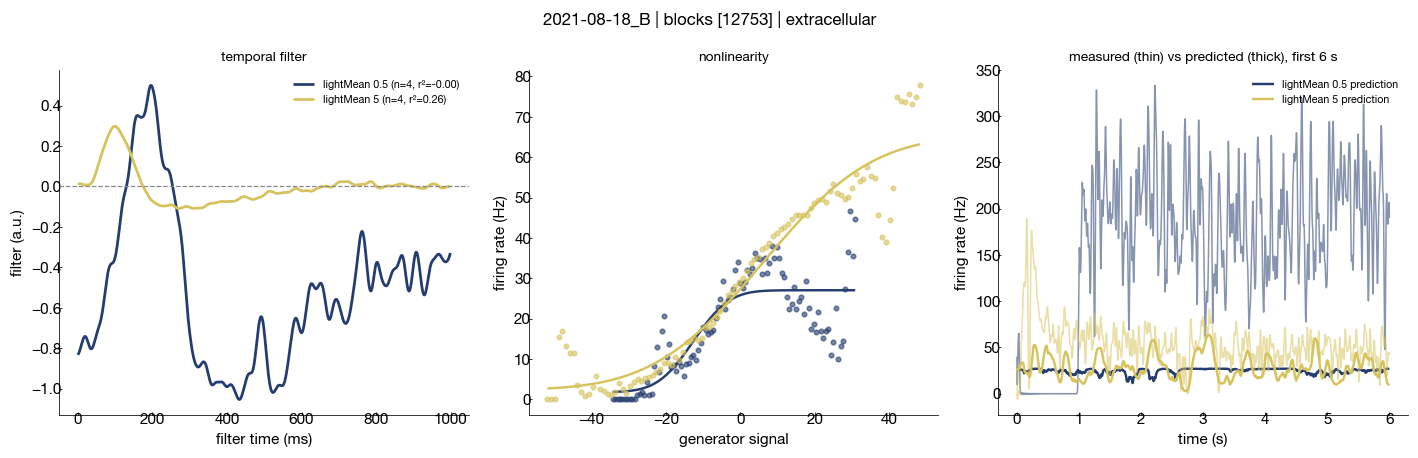

In [7]:
# Pick a row from the table above by its `entry`. The default takes a block
# that stepped between two light means, preferring one recorded
# extracellularly and, where possible, a cell the saved list also has -- so
# that §5 has something to compare against.
stepped = conditions[conditions.n_lightMean.gt(1)]
if 'rec_type' in conditions:
    spiking = stepped[stepped.rec_type.eq('extracellular')]
    stepped = spiking if len(spiking) else stepped
saved_labels = {c.lower() for c in
                roster[roster.calendar_date.isin(conditions.exp_name.str[:10])].cell_label}
in_roster = stepped[stepped.cell_label.str.lower().isin(saved_labels)]
stepped = in_roster if len(in_roster) else stepped
ENTRY = int(stepped.entry.iloc[0]) if len(stepped) else 0

row = conditions[conditions.entry.eq(ENTRY)].iloc[0]
EXP_NAME = row.exp_name
BLOCK_IDS = [int(row.block_id)]
REC_TYPE = row.get('rec_type', 'extracellular')
DOWNSAMPLE = 10                 # 10 kHz -> 1 kHz, by block average
MAX_EPOCHS = 8                  # None for every epoch; each is up to 60 s

print(f'entry {ENTRY}: {EXP_NAME} block {BLOCK_IDS[0]} | '
      f'{row.cell_label} ({row.cell_type_short}) | {REC_TYPE} | '
      f'lightMean {row.lightMean}')
analysis = vmn.analyze_condition(
    EXP_NAME, BLOCK_IDS, rec_type=REC_TYPE,
    downsample=DOWNSAMPLE, max_epochs=MAX_EPOCHS, verbose=True)
print(f'\n{analysis}')

condition_figure = vmn.plot_condition(analysis)

### 3a. The adaptation, as two numbers

Filter time-to-peak and gain, per mean level. A cell adapted to a dimmer mean should integrate
for longer and amplify more; both should fall as the mean rises.

`r2` is held out, `r2_train` in sample, and `nl_r2` is the sigmoid's fit to the ~100 binned
nonlinearity points. **`nl_r2` is not model performance** — binning averages the noise away, so
it sits near 1 almost regardless of how well the model predicts a trace, and it is shown here
only so it is not mistaken for the score again.

In [ ]:
rows = []
for mean_level in analysis.light_means:
    model = analysis.ln_model[mean_level]
    rows.append({
        'lightMean': mean_level,
        'n_epochs': analysis.n_epochs[mean_level],
        'n_train': model.n_train, 'n_test': model.n_test,
        'r2': model.r2, 'r2_train': model.r2_train, 'nl_r2': model.nl_r2,
        'time_to_peak_ms': model.time_to_peak_ms,
        'peak_gain': float(np.nanmax(np.abs(model.filter))),
        'biphasic_index': model.biphasic_index,
    })
summary = pd.DataFrame(rows)
display(summary.round(3))

if len(summary) > 1:
    dim, bright = summary.iloc[0], summary.iloc[-1]
    print(f'lightMean {dim.lightMean:g} -> {bright.lightMean:g}  '
          f'({bright.lightMean / dim.lightMean:.0f}x brighter):')
    print(f'  time-to-peak {dim.time_to_peak_ms:.0f} -> {bright.time_to_peak_ms:.0f} ms')
    print(f'  peak gain    {dim.peak_gain:.3g} -> {bright.peak_gain:.3g} '
          f'({dim.peak_gain / bright.peak_gain:.1f}x lower)')

## 4. LED light level

The LED's own neutral density filters set the light level. A `filter_wheel_ndf` in the block
metadata is real — the wheel exists on the rig — but it is **not in the LED's path**, so it
must not be added to this stimulus's attenuation. `led_attenuation` returns it separately with
`wheel_ignored` set, rather than dropping it silently, because the same metadata is correct
for a Stage protocol and wrong here.

A filter with no entry in the rig's LED table leaves `optical_density` blank and is named in
`unknown_tokens`, so an unknown filter cannot masquerade as no attenuation.

In [ ]:
light_rows = []
for exp_name, group in blocks.groupby('exp_name'):
    entry = vmn.led_attenuation(group.iloc[0])
    entry['n_blocks'] = len(group)
    light_rows.append(entry)
light = pd.DataFrame(light_rows)

sc.scroll_table(light.round(4), height=320,
                num_cols=('optical_density', 'attenuation', 'filter_wheel_ndf', 'n_blocks'))

unresolved = light[light.unknown_tokens.ne('')]
print(f'{len(light)} experiments | {int(light.wheel_ignored.sum())} carry a filter-wheel '
      f'reading that does not apply to the LED')
if len(unresolved):
    print(f'{len(unresolved)} with filters missing from the rig LED table: '
          f'{sorted(set(unresolved.unknown_tokens))}')

## 5. Check the Python fit against the MATLAB's

For a cell that is both in the data-entry list and reachable, the MATLAB's own saved LN model
can be loaded and put beside the one fitted here. The two are not expected to match
numerically — the MATLAB fitted its own epoch selection, its own windowing, and grouped by
step *direction* while §3 groups by *mean level* — but the filter shape and the direction of
the adaptation should agree.

The MATLAB's stored `SigmoidNlNode` object cannot be read back (it was written through the
MCOS mechanism, which `scipy.io.loadmat` returns as an opaque reference), so its
`alpha/beta/gamma/epsilon` are unavailable; the measured `nlX`/`nlY` are plain arrays and come
back intact.

In [ ]:
# Compare against the MATLAB entry for the *same* cell where one exists: the
# roster and the database label cells independently, so match on the label.
saved_rows = roster[roster.calendar_date.eq(EXP_NAME[:10])
                    & roster.cell_label.str.lower().eq(str(row.cell_label).lower())]
note = located.loc[located.exp_name.eq(EXP_NAME) & located.date_note.ne(''), 'date_note']
if len(note):
    print(f'NOTE on {EXP_NAME}: {note.iloc[0]}\n')

if len(saved_rows):
    saved = vmn.load_cell(int(saved_rows.iloc[0]['index']))
    print(f"MATLAB saved: {saved['exp_date']}/{saved['cell_label']} | "
          f"{saved['cell_type']} | {saved['rec_type']}")
    for direction, model in saved['ln_model'].items():
        print(f'  {vmn.STEP_LABELS[direction]:>10}: r2={model.r2:.3f} | '
              f'time-to-peak {model.time_to_peak_ms:.0f} ms | '
              f'biphasic {model.biphasic_index:+.2f}')
    print('\nPython fit (this notebook, grouped by lightMean):')
    for mean_level in analysis.light_means:
        model = analysis.ln_model[mean_level]
        print(f'  lightMean {mean_level:<5g}: r2={model.r2:.3f} | '
              f'time-to-peak {model.time_to_peak_ms:.0f} ms | '
              f'biphasic {model.biphasic_index:+.2f}')
else:
    print(f'{EXP_NAME} {row.cell_label} has no entry in the saved data-entry list, '
          f'so there is no MATLAB fit to compare against.')
    print('Cells on this date that do: '
          + ', '.join(roster[roster.calendar_date.eq(EXP_NAME[:10])].cell_label))